# Generating Coverage Plots

### Housewarming!
Here you can reproduce the coverage levels plots, given a pre-trained model! This first cell details the necessary imports

<span style="color:red"> *This requires an already trained model!*</span>


In [ ]:
# ------------
# Housewarming
# -----------
# generic
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)

# prettier plots
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams["text.usetex"] = False

# internal
from helpers import *

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"This notebook is using: {device}")

This notebook is using: cpu


### Retrieving pathnames and defining global variables
Here, we get the data and model paths.

Simply rename <span style="color:pink"> *data_path*</span> and <span style="color:pink"> *checkpoint_path*</span> for where you're storing your data and models respectively; Do not worry about the specific paths past that, as long as *all* of your data and models are stored in the specified directories. You shouldn't have to worry about renaming anything else (guide for training is in its respective noteboook).

In [2]:
boxsizes = {
    'TNG': 75.,
    'ASTRID': 250.,
}
graph_radius = 2000

# TODO modify these paths 
data_dir = "/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/carol_processed_data/"
model_dir = "/n/home03/hbrittain/model_outs"

Here we load the models, data, and then generate predictions.

To experiment with what you generate, feel free to modify:
- <span style="color:pink"> *sim*</span> (str): Simulation suites (Astrid and Illustris)
- <span style="color:pink"> *z*</span> (int): Redshifts (3-6)
- <span style="color:pink"> *model_type*</span> (str): Either the GNN or FCN

Optional:
- <span style="color:hotpink"> *observables_only*</span>: If you set this to true, you will retrieve the models trained only on observables (i.e. JWST frequencies)

In [3]:
# TODO modify variables to experiment!
sim = 'tng'
z = 5
model_type = 'fcn'
observable_features_only = False

config = DataConfig(data_dir=data_dir, 
                    ckpt_dir=model_dir,
                    model_type=model_type,
                    sim=sim,
                    z=z,
                    graph_radius=graph_radius,
                    observables_only=observable_features_only
                    )

test_dataloader = load_data(config, only_test=True)
model = load_model(config)
stats = load_train_stats(config)
trues, preds, log_probs = get_predictions(config, test_dataloader, model)

/n/home03/hbrittain/.conda/envs/ourenv/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/home03/hbrittain/.conda/envs/ourenv/lib/python3.9 ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/n/home03/hbrittain/.conda/envs/ourenv/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard su

Predicting: |          | 0/? [00:00<?, ?it/s]

### Coverage!

Here you can see under the hood for how we generate a single coverage plot from our predictions above! We can also compare against a simple true versus predicted graph to see the differences in representation.

The coverage plot shows a credibility level versus expected coverage. At a given credibility level from $\alpha=[0-1]$, the expected coverage measures the amount of instances where the true halo mass lies within the $1-\alpha$ highest density region of the flow given the input parameters (i.e., our summary graph or summary statistics). 

For example, let's say we have $\alpha=0.9$ and a credible region of $1-\alpha=0.1$. This means we construct a region in the posterior distribution that contains 10% of the total probability mass, selecting the most probable values of the halo mass first. This is called the *highest density region* because it is the **smallest** such region that encloses the required probability mass.  In a well-calibrated model, the true halo mass should fall inside this 10% credible region **exactly 10% of the time** across many trials.  

A plot will reveal an *underconfident* model if the credible regions are **larger than necessary**, meaning the expected coverage is higher than the nominal level.  
A plot will reveal an *overconfident* model if the credible regions are **too small**, meaning the expected coverage is lower than the nominal level.

Now, let's plot these outputs to see what we're looking at!

In [4]:
# generate coverage data
def get_lampe_pairs(config, dataloader, model):
    '''
    theta: The features that parameterize your flow model. 
        For the FCN, these are the summary statistics. 
        For the GNN, these are the graph summaries (which must be sent through the model)
    x: The true values 
    '''
    thetas = [] 
    exes = []  
    
    if config.model_type=='GNN':
        for batch in dataloader:
            thetas.append(batch[1].cpu())
            exes.append(model.model(batch).cpu())
    elif config.model_type=='FCN':
        for batch in test_dataloader:
            thetas.append(batch[1].cpu())
            exes.append(batch[0].cpu())
    theta = torch.cat(thetas, dim=0)
    x = torch.cat(exes, dim=0)
    return zip(theta, x)

pairs = get_lampe_pairs(config, test_dataloader, model)
lvls, covers = expected_coverage_mc(model.flow, pairs, device=device)

967pair [00:00, 1260.38pair/s]


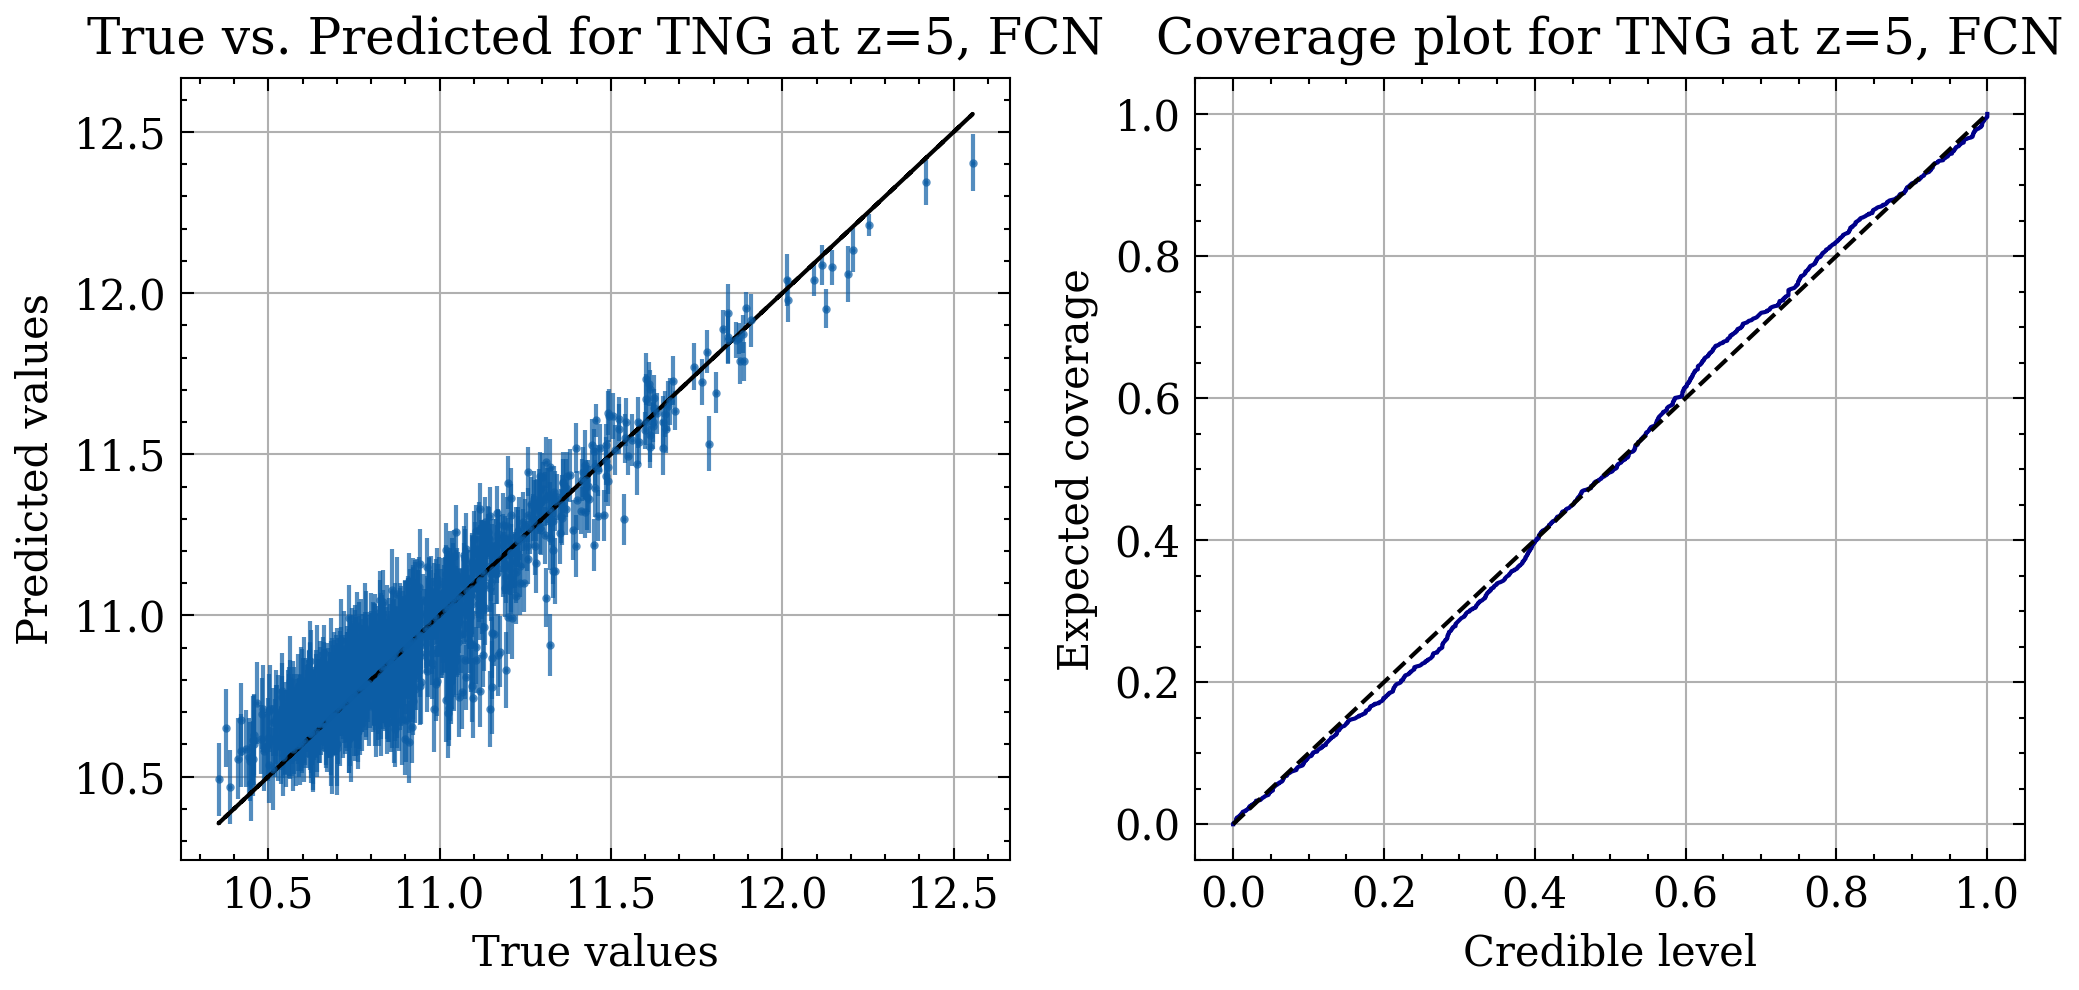

In [5]:
# plot both!
fig, axes = plt.subplots(1, 2, figsize=(7,3.5))

# true versus pred
ax0, ax1 = axes[0], axes[1]
ax0.errorbar(x=trues, 
             y=preds.mean(dim=1), 
             yerr=preds.std(dim=1), 
             marker='o', 
             linestyle='', 
             markersize=1,
             alpha=0.7) 
ax0.plot(trues, trues, color='k', linestyle='--')
ax0.grid(visible=True)
ax0.set_ylabel('Predicted values')
ax0.set_xlabel('True values')
ax0.set_title(f'True vs. Predicted for {config.sim} at z={config.z}, {config.model_type}')

# coverage plot
ax1.plot(lvls, covers, color='darkblue', label='Coverage')
ax1.plot([0, 1], [0, 1], color='k', linestyle='--')
ax1.grid(visible=True)
ax1.set_xlabel(r'Credible level')
ax1.set_ylabel(r'Expected coverage')
ax1.set_title(f'Coverage plot for {config.sim} at z={config.z}, {config.model_type}')
fig.set_layout_engine(layout='tight')

### Final Figures
And now, using our function from <span style="color:dodgerblue"> *helpers.py*</span>, we can generate all of the coverage plots for either the baseline or the graph neural net! Go ahead and experiment :)

In [6]:
levels, coverages = all_coverages(model_type='fcn', 
                                  suite='tng', 
                                  data_dir=data_dir, 
                                  model_dir=model_dir)

2759pair [00:02, 1160.70pair/s]
1789pair [00:01, 1091.73pair/s]
967pair [00:00, 1266.77pair/s]
117pair [00:00, 1278.22pair/s]


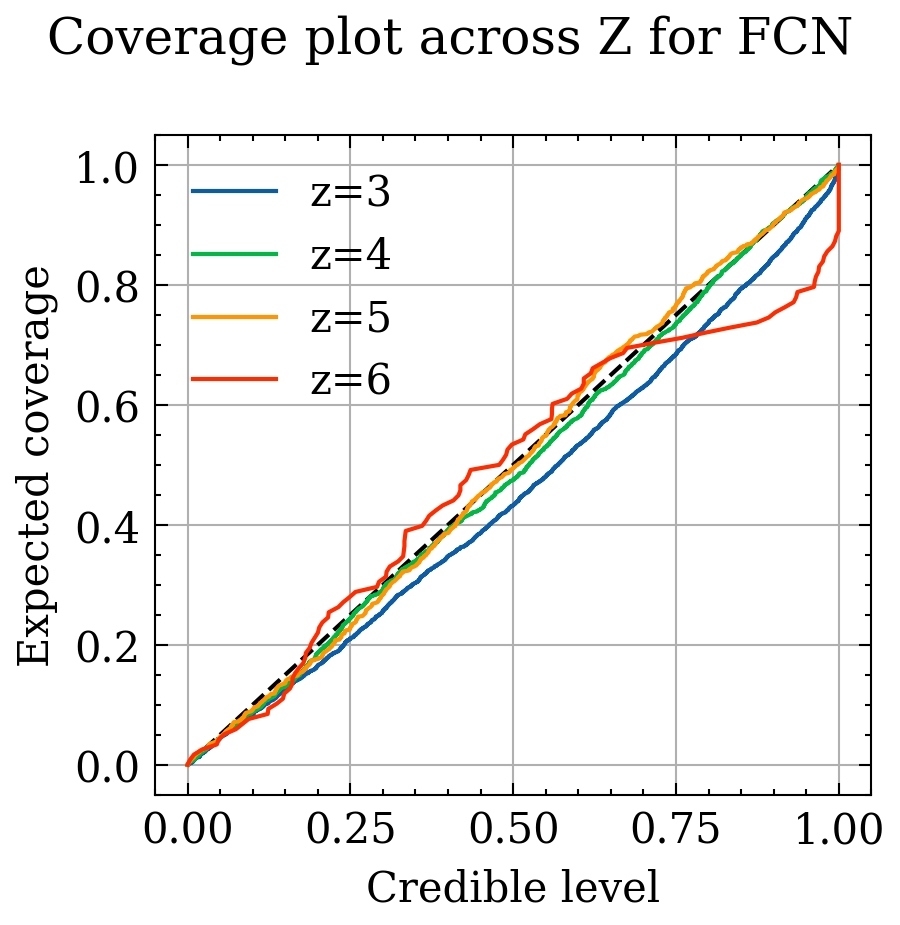

In [47]:
def plot_coverages(levels, coverages):
    fig = None
    for i, zed in enumerate([3,4,5,6]):
        if i==0:
            fig = coverage_plot(levels[i], coverages[i], legend=f'z={zed}')
        else:
            coverage_plot(levels[i], coverages[i], legend=f'z={zed}', figure=fig)
            
    fig.suptitle(f"Coverage plot across Z for FCN")   
plot_coverages(levels, coverages)

In [ ]:
#!/usr/bin/env python3
import sys
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# Make sure your project root (where helpers.py lives) is on PYTHONPATH
# ─────────────────────────────────────────────────────────────────────────────
project_root = "/path/to/your/project/root"    # e.g. "/home/you/repos/galaxyGNN"
sys.path.insert(0, project_root)

from utils import all_coverages   

# ─────────────────────────────────────────────────────────────────────────────
# TODO: set these two!
data_dir  = "/path/to/carol_processed_data"    # where your gnn_*/ and fcn_*/ folders live
model_dir = "/path/to/model_outs"              # where your checkpoint folders live
# ─────────────────────────────────────────────────────────────────────────────

model_types = ["GNN", "FCN"]
suites      = ["ASTRID", "TNG"]
redshifts   = [3, 4, 5, 6]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for i, model in enumerate(model_types):
    for j, suite in enumerate(suites):
        ax = axes[i, j]
        levels, covers = all_coverages(model, suite, data_dir, model_dir)
        for lvl, cvr, z in zip(levels, covers, redshifts):
            ax.plot(lvl, cvr, label=f"z={z}")
        # diagonal line for perfect calibration
        ax.plot([0,1], [0,1], linestyle="--", alpha=0.5)
        ax.set_title(f"{model} – {suite}")
        ax.set_xlabel("Credibility Level")
        ax.set_ylabel("Empirical Coverage")
        ax.legend(title="Redshift")